In [11]:
import pandas as pd
from common.data_retreival import fetch_data_for_prep
from common.calculations import calculate_daily_average_volume, calculate_daily_atr, \
calculate_log_returns, get_avg_daily_return, calculate_statistics
from common.recommendations import get_symbols_to_trade, get_results_recommendations
from common.plotting import plot_correlation_matrix
ref_symbol = 'VOO'

In [12]:
days_to_analyze = 30
granularity = "15m"
symbols = [
    #'VXUS', #International Found 0.08 
    'SCHH', #REIT 0.07
    #'QQQM', #NASDAQ 0.15
    #'VXUS', #International 0.08
    'XLP', #Consumer Staples 0.09
    'XLV', #Health Care 0.09
    'VUG', #Growth 0.04
    'VIG', #Dividend 0.06
    'IJR', #Small Caps 0.06
    'XLI', #Industrial 0.09
    'XLU', #Utilities 0.09
    'XLC', #Communication 0.09
    'AMZN',
    'HEI',
    'ULTA',
    'SOFI',
    #'GOOGL',
    'WMT',
    'COST',
    'CMG',
    ref_symbol #SP500 0.03
    ]

In [13]:
data = fetch_data_for_prep(symbols, days_to_analyze, granularity)
prices = data['Adj Close']
volume = data['Volume']
log_returns = calculate_log_returns(prices)
correlation, volatility, avg_return = calculate_statistics(log_returns)
avg_daily_return = get_avg_daily_return(avg_return, granularity)
avg_volume = {symbol: calculate_daily_average_volume(data.xs(symbol, level=1, axis=1)) for symbol in symbols}
atr = {symbol: calculate_daily_atr(data.xs(symbol, level=1, axis=1)) for symbol in symbols}

[*********************100%%**********************]  17 of 17 completed


Getting data from 2024-08-19 11:58:00 to 2024-09-18 09:50:00


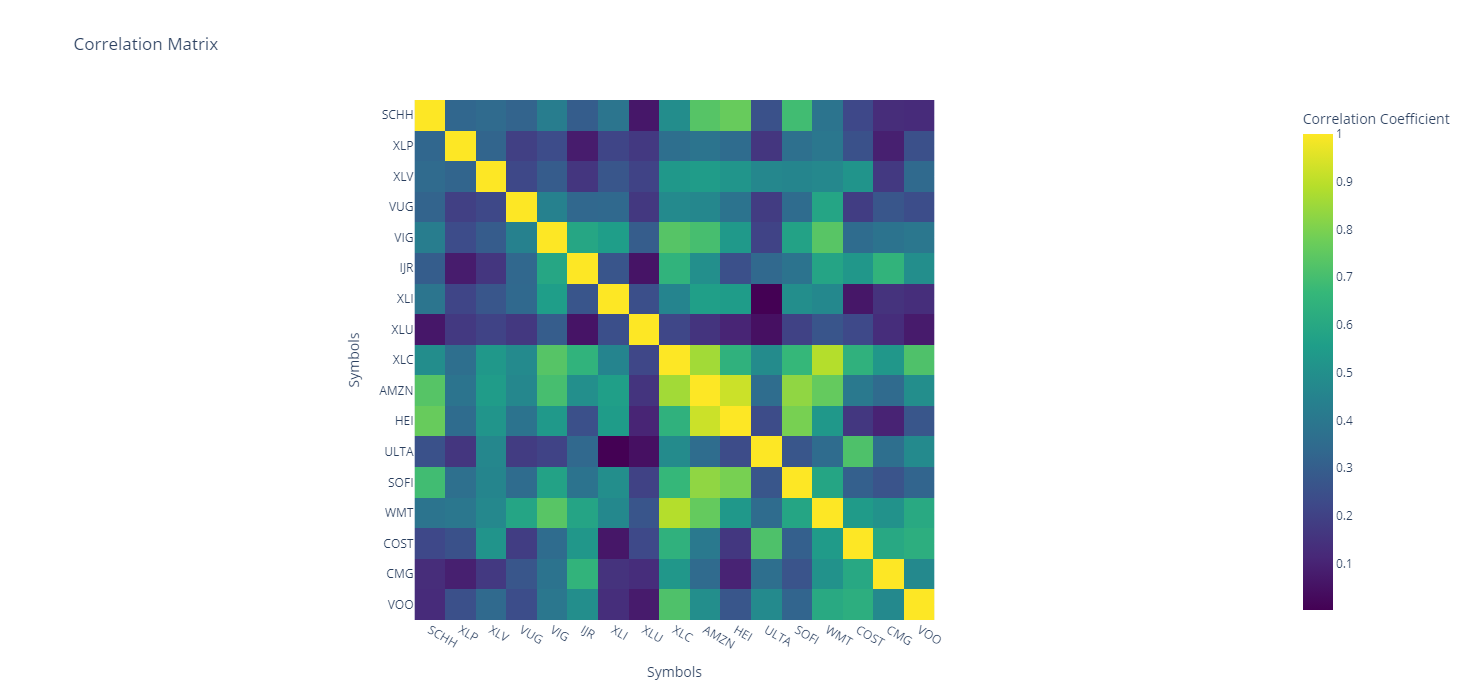

In [14]:
plot_correlation_matrix(correlation, symbols)

In [15]:
print("\nVolatility (based on selected time interval):")
print(volatility.sort_values(ascending=False))
print("\nAverage Return (based on selected time interval):")
print(avg_return.sort_values(ascending=False))
print("\nAverage Daily Return (based on selected time interval):")
print(avg_daily_return.sort_values(ascending=False))
print("\nDaily Average Volume:")
for symbol, value in avg_volume.items():
    print(f"{symbol}: {value}")
print("\nDaily Average True Range (ATR):")
for symbol, value in atr.items():
    print(f"{symbol}: {value}")


Volatility (based on selected time interval):
Ticker
SOFI    0.005356
ULTA    0.004855
HEI     0.003361
AMZN    0.003307
CMG     0.003202
COST    0.002432
IJR     0.002139
VUG     0.002056
XLI     0.001811
WMT     0.001724
SCHH    0.001669
XLC     0.001663
VOO     0.001508
XLU     0.001465
XLV     0.001415
XLP     0.001373
VIG     0.001283
dtype: float64

Average Return (based on selected time interval):
Ticker
SOFI    0.000246
CMG     0.000164
HEI     0.000156
SCHH    0.000138
WMT     0.000115
XLU     0.000101
AMZN    0.000095
XLI     0.000063
XLP     0.000060
VIG     0.000045
COST    0.000042
ULTA    0.000041
IJR     0.000039
VOO     0.000025
XLV     0.000023
XLC     0.000022
VUG     0.000005
dtype: float64

Average Daily Return (based on selected time interval):
Ticker
SOFI    0.006391
CMG     0.004253
HEI     0.004063
SCHH    0.003600
WMT     0.003001
XLU     0.002621
AMZN    0.002476
XLI     0.001645
XLP     0.001565
VIG     0.001182
COST    0.001097
ULTA    0.001061
IJR     0.00

In [6]:
list_of_symbols = get_symbols_to_trade(
    symbols, 
    prices, 
    volatility, 
    atr, 
    avg_volume, 
    avg_return, 
    prices, 
    ref_symbol,
    over_night_mv_threshold=0.005
)
list_of_symbols

Symbol PTON has low ATR
Symbol PRDO has low ATR
Symbol GOOG has low overtnight move
Symbol XLP has low overtnight move
Symbol VGIT has low ATR
Symbol VYM has low overtnight move
Symbol XLU has low overtnight move
Symbol QQQM has low overtnight move
Symbol XLV has low overtnight move
Symbol VOO has low overtnight move


{'VOO': {'last_closing': np.float64(514.7999877929688),
  'overnight_move_pct': np.float64(0.0010101389735446737),
  'avg_return': np.float64(0.00012917812837032194),
  'avg_volume': np.float64(3288562.6666666665),
  'atr': np.float64(4.099955240885417),
  'volatility': np.float64(0.0010832216883469182)}}

In [7]:
budget = 40000
potential_investments_col = ["Symbol", "Purchase Price", "Position Size", "Exit Price", "Win Revenue", "Win %", "Stop Loss", "Lost", "Loss %"]
potential_investments = []
for stock_in_play in list_of_symbols:
    stock_price = list_of_symbols[stock_in_play]['last_closing'] 
    potential_investments.append(
        get_results_recommendations(
            stock_in_play, 
            stock_price, 
            round(budget/stock_price, 0),
            atr
        )
    )   
results_pd = pd.DataFrame(potential_investments, columns=potential_investments_col)
results_pd.sort_values(by=['Win Revenue'], ascending=False)

,Symbol,Purchase Price,Position Size,Exit Price,Win Revenue,Win %,Stop Loss,Lost,Loss %
0,VOO,514.799988,78.0,516.849965,159.898254,0.396629,513.774999,-79.949127,-0.199501
